# 🎥 Video 11: Chemical Space Exploration, Dimensionality Reduction & Clustering
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 6 — Chemical Space Exploration (Topics 30, 31, 32, 33, 34, 35)
* **Target Audience:** Cheminformatics Engineers, AI Researchers, Screening Scientists

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 05:00** | What is Chemical Space? High-Dimensional Fingerprint Manifolds
* **05:00 - 10:00** | Dimensionality Reduction: PCA vs t-SNE (Global Variance vs Local Neighborhoods)
* **10:00 - 15:00** | Visualizing Chemical Space Colored by Bioactivity ($pIC_{50}$) & Physicochemical Properties
* **15:00 - 20:00** | Molecular Clustering: Taylor-Butina Clustering (The Gold Standard)
* **20:00 - 24:30** | Extracting Cluster Centroids & Structural Diversity Analysis
* **24:30 - 28:00** | Diverse Subset Selection via `MaxMinPicker`
* **28:00 - 30:00** | Hands-On Challenge & Summary

---

### 🎯 Learning Objectives
1. Project 2048-dimensional Morgan fingerprints into 2D chemical space using PCA and t-SNE.
2. Color-code chemical space projections by bioactivity ($pIC_{50}$) and molecular weight to detect SAR clusters.
3. Master **Taylor-Butina sphere exclusion clustering** (`rdkit.ML.Cluster.Butina`).
4. Identify representative cluster centroids and inspect scaffold diversity.
5. Select diverse representative subsets of compounds for wet-lab screening using `MaxMinPicker`.

In [1]:
# Step 0: Imports and Setup
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator, Descriptors
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
from rdkit.Chem.Draw import IPythonConsole
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

IPythonConsole.ipython_useSVG = True

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. Loading the Chemical Library & Featurization
We load our real ChEMBL EGFR compound dataset with measured $pIC_{50}$ bioactivity values and generate 1024-bit Morgan fingerprints (ECFP4).

In [2]:
candidate_paths = [
    "datasets/EGFR_compounds.csv",
    "../datasets/EGFR_compounds.csv",
    "../../datasets/EGFR_compounds.csv",
    os.path.expanduser("~/Projects/AI-Engineer-for-Life-Sciences-Libraries/Cheminformatics/RDKit/datasets/EGFR_compounds.csv")
]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path:
    df_raw = pd.read_csv(csv_path).head(400) # Sample 400 compounds for fast rendering
    
    mols = []
    valid_records = []
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    fps = []
    
    for idx, row in df_raw.iterrows():
        m = Chem.MolFromSmiles(row["smiles"])
        if m:
            mols.append(m)
            fps.append(mfpgen.GetFingerprint(m))
            valid_records.append({
                "ChEMBL_ID": row["molecule_chembl_id"],
                "SMILES": row["smiles"],
                "pIC50": row.get("pIC50", np.nan),
                "MW": Descriptors.MolWt(m),
                "LogP": Descriptors.MolLogP(m)
            })
            
    df_chem = pd.DataFrame(valid_records)
    print(f"✅ Prepared {len(mols)} valid molecules with ECFP4 fingerprints.")

✅ Prepared 400 valid molecules with ECFP4 fingerprints.


## 2. Dimensionality Reduction: PCA vs t-SNE
* **PCA (Principal Component Analysis):** Linear projection maximizing global variance.
* **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Non-linear projection preserving local neighborhood topologies (structurally similar molecules group tightly into visual clusters).

In [3]:
# Convert bit vectors to dense numpy matrix
X_fp = np.zeros((len(fps), 1024), dtype=np.float32)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, X_fp[i])

# 1. PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_fp)

# 2. t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=25, max_iter=1000)
X_tsne = tsne.fit_transform(X_fp)

df_chem["PCA_1"] = X_pca[:, 0]
df_chem["PCA_2"] = X_pca[:, 1]
df_chem["tSNE_1"] = X_tsne[:, 0]
df_chem["tSNE_2"] = X_tsne[:, 1]

print(f"PCA explained variance ratio (PC1 + PC2): {pca.explained_variance_ratio_.sum():.2%}")

PCA explained variance ratio (PC1 + PC2): 19.65%


## 3. Visualizing Chemical Space Colored by Bioactivity ($pIC_{50}$)
Let's see if active compounds ($pIC_{50} \ge 8.0$) cluster together in chemical space!

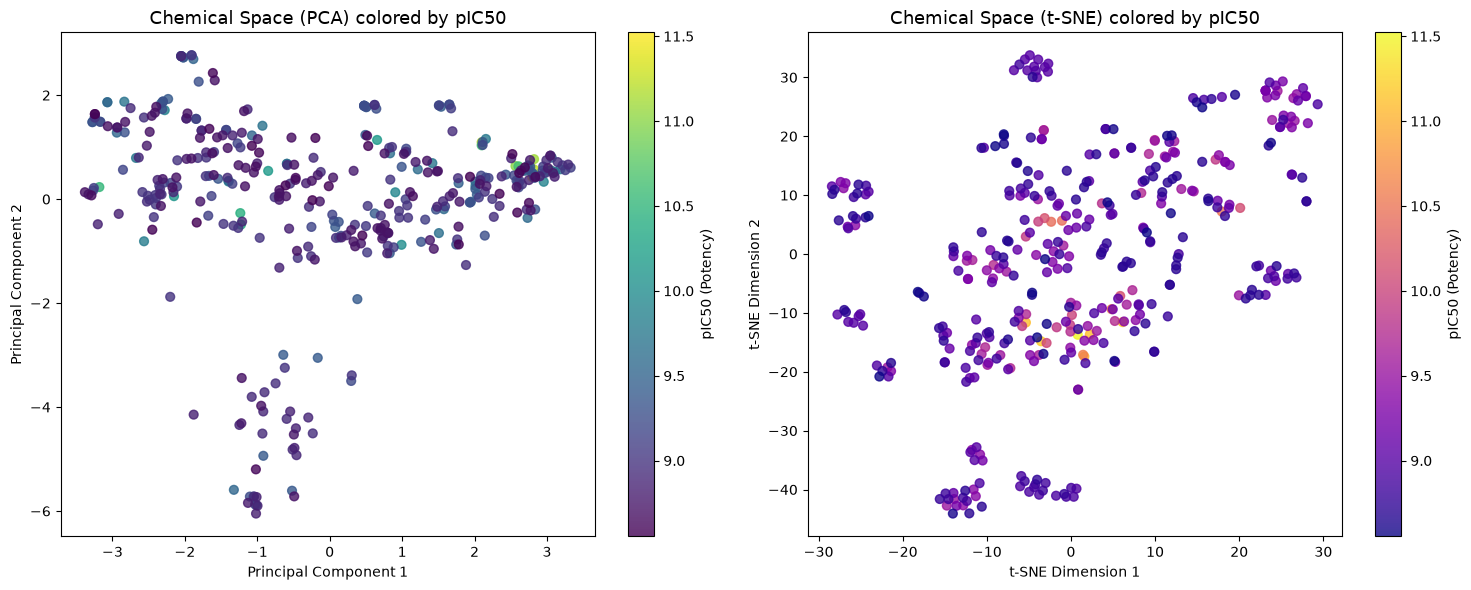

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot PCA
sc1 = axes[0].scatter(df_chem["PCA_1"], df_chem["PCA_2"], c=df_chem["pIC50"], cmap="viridis", alpha=0.8, s=40)
axes[0].set_title("Chemical Space (PCA) colored by pIC50", fontsize=13)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
fig.colorbar(sc1, ax=axes[0], label="pIC50 (Potency)")

# Plot t-SNE
sc2 = axes[1].scatter(df_chem["tSNE_1"], df_chem["tSNE_2"], c=df_chem["pIC50"], cmap="plasma", alpha=0.8, s=40)
axes[1].set_title("Chemical Space (t-SNE) colored by pIC50", fontsize=13)
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
fig.colorbar(sc2, ax=axes[1], label="pIC50 (Potency)")

plt.tight_layout()
plt.show()

## 4. Taylor-Butina Molecular Clustering
The **Taylor-Butina algorithm** is the industry standard for chemical library clustering:
1. Calculates all pairwise Tanimoto distances: $d(A, B) = 1 - T(A, B)$.
2. For each molecule, counts the number of neighbors within a defined distance cutoff (sphere radius, e.g. $0.35$ or $0.40$).
3. Sorts molecules by neighbor count descending.
4. The molecule with the most neighbors becomes the **centroid** of Cluster 1, and its neighbors are placed in Cluster 1 and removed from the pool.
5. Repeats until all molecules are assigned to clusters or singletons!

In [5]:
# Compute condensed distance matrix (1D list of lower triangle)
n_mols = len(fps)
dists = []
for i in range(1, n_mols):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1.0 - x for x in sims])

# Run Butina clustering with distance cutoff = 0.35 (Tanimoto similarity >= 0.65)
dist_cutoff = 0.35
clusters = Butina.ClusterData(dists, n_mols, dist_cutoff, isDistData=True)

print(f"Total Clusters Formed: {len(clusters)}")
print(f"Largest Cluster Size:  {len(clusters[0])} molecules")
print(f"Singletons (size=1):   {sum(1 for c in clusters if len(c) == 1)}")

Total Clusters Formed: 132
Largest Cluster Size:  25 molecules
Singletons (size=1):   69


## 5. Visualizing Cluster Centroids
The centroid of each cluster represents the core structural scaffold of that chemical family.

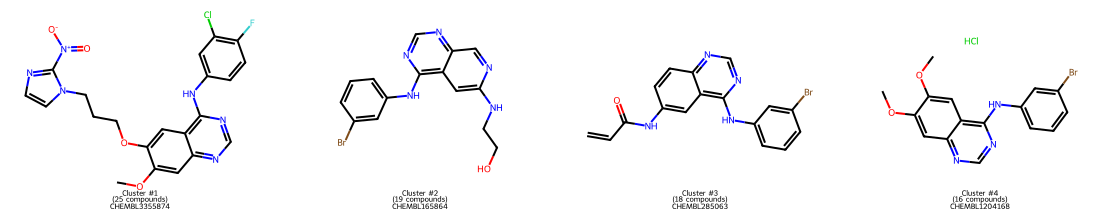

In [6]:
# Display the top 4 cluster centroids (most populated chemical families)
top_clusters = clusters[:4]
centroid_mols = [mols[c[0]] for c in top_clusters]
centroid_legends = [
    f"Cluster #{i+1}\n({len(c)} compounds)\n{df_chem.iloc[c[0]]['ChEMBL_ID']}"
    for i, c in enumerate(top_clusters)
]

Draw.MolsToGridImage(centroid_mols, legends=centroid_legends, molsPerRow=4, subImgSize=(280, 220))

## 6. Diverse Subset Selection with `MaxMinPicker`
When cherry-picking a diverse subset of $N$ compounds to purchase or test in high-throughput screening, `MaxMinPicker` iteratively selects the molecule whose minimum distance to the already selected set is maximized.

MaxMin Selected Diverse Compound Indices: [149, 258, 16, 250, 360]


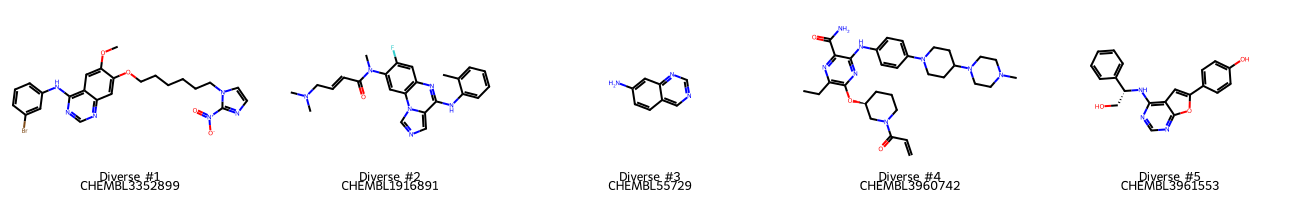

In [7]:
picker = MaxMinPicker()
num_diverse_picks = 5

# LazyBitVectorPick selects diverse compounds directly from fingerprints
picked_indices = list(picker.LazyBitVectorPick(fps, n_mols, num_diverse_picks, seed=42))
print("MaxMin Selected Diverse Compound Indices:", picked_indices)

diverse_mols = [mols[idx] for idx in picked_indices]
diverse_legends = [f"Diverse #{i+1}\n{df_chem.iloc[idx]['ChEMBL_ID']}" for i, idx in enumerate(picked_indices)]

Draw.MolsToGridImage(diverse_mols, legends=diverse_legends, molsPerRow=5, subImgSize=(260, 200))

## 7. 🎯 Video Hands-On Challenge & Solution
### Problem:
1. Re-cluster the library with a tighter distance cutoff of $0.25$ (Tanimoto $\ge 0.75$).
2. How does the number of clusters change?
3. Calculate the average $pIC_{50}$ for compounds belonging to Cluster 1.

In [8]:
clusters_tight = Butina.ClusterData(dists, n_mols, 0.25, isDistData=True)
print(f"Clusters with cutoff 0.25: {len(clusters_tight)} (vs {len(clusters)} with cutoff 0.35)")

cluster_1_indices = clusters_tight[0]
c1_pic50s = df_chem.iloc[list(cluster_1_indices)]["pIC50"].dropna()

print(f"Cluster 1 compound count: {len(cluster_1_indices)}")
print(f"Cluster 1 Mean pIC50:     {c1_pic50s.mean():.2f}")
print(f"Cluster 1 Std Dev pIC50:  {c1_pic50s.std():.2f}")

Clusters with cutoff 0.25: 218 (vs 132 with cutoff 0.35)
Cluster 1 compound count: 14
Cluster 1 Mean pIC50:     9.28
Cluster 1 Std Dev pIC50:  0.15


## 8. Summary & Key Takeaways
* **Chemical space projections** (t-SNE) reveal SAR islands: structurally related analogs clustered together with similar potencies.
* **Taylor-Butina Clustering** is fast, deterministic, and does not require pre-specifying $K$ (unlike K-Means).
* **`MaxMinPicker`** guarantees optimal chemical diversity for library design and screening deck cherry-picking.

**Next Up in Video 12:** **Bemis-Murcko Scaffolds & Molecular Decomposition** — core scaffold extraction, framework hopping, and matched molecular pair analysis!